# Week 3 Day 5 — CNN Basics
**Jul 17, 2026**

Day 4 built a reusable `CNN` class without dwelling on what `Conv2d` actually computes or why it helps. Today: the shape mechanics of convolution, then a real head-to-head against an MLP on a task where a convolution's core assumption — the same local pattern can appear anywhere in the image — genuinely matters, not just in theory.

Scaffold as usual: TODO stubs, hints not formulas, self-check cells.

## Part 1: A dataset where position varies

Given. 16x16 grayscale images, each containing a short line: horizontal, vertical, or diagonal (3 classes). Critically, the line's **position** is randomized every time — a horizontal line might appear near the top in one image and near the bottom in another. The label only depends on orientation, never position.

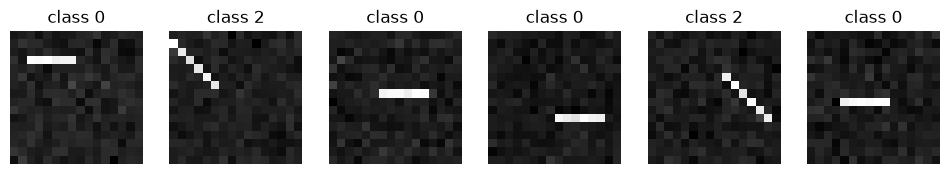

torch.Size([450, 1, 16, 16]) torch.Size([450])


In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(0)

def make_line_image(kind, size=16):
    img = torch.zeros(size, size)
    if kind == 0:  # horizontal
        row = torch.randint(2, size - 2, (1,)).item()
        col_start = torch.randint(0, size - 6, (1,)).item()
        img[row, col_start:col_start + 6] = 1.0
    elif kind == 1:  # vertical
        col = torch.randint(2, size - 2, (1,)).item()
        row_start = torch.randint(0, size - 6, (1,)).item()
        img[row_start:row_start + 6, col] = 1.0
    else:  # diagonal
        r0 = torch.randint(0, size - 6, (1,)).item()
        c0 = torch.randint(0, size - 6, (1,)).item()
        for i in range(6):
            img[r0 + i, c0 + i] = 1.0
    return img

n_per_class = 150
imgs, labels = [], []
for cls in range(3):
    for _ in range(n_per_class):
        imgs.append(make_line_image(cls))
        labels.append(cls)

X = torch.stack(imgs).unsqueeze(1) + 0.05 * torch.randn(3 * n_per_class, 1, 16, 16)
y = torch.tensor(labels)

fig, axes = plt.subplots(1, 6, figsize=(12, 2))
for i, ax in enumerate(axes):
    idx = torch.randint(0, len(X), (1,)).item()
    ax.imshow(X[idx, 0], cmap="gray")
    ax.set_title(f"class {y[idx].item()}")
    ax.axis("off")
plt.show()

print(X.shape, y.shape)

## Part 2: What `Conv2d` does to shape

TODO: implement `conv_output_size(input_size, kernel_size, stride, padding)` — a plain arithmetic function (no `nn.Conv2d` involved), predicting the output spatial size of a square input.

The relationship: a kernel of size `k` needs `k` positions to "fit" at each stop; padding `p` on each side extends the effective input size by `2p` before the kernel starts sliding; stride `s` is how far the kernel jumps between positions. Work out how many valid positions a size-`k` window has when sliding by `s` across a sequence of length `input_size + 2*padding` — that count is the output size. (Floor division matters here — the kernel doesn't get to stop at a fractional position.)

In [2]:
def conv_output_size(input_size, kernel_size, stride, padding):
    # TODO
    stride = stride if isinstance(stride, int) else stride[0]
    padding = padding if isinstance(padding, int) else padding[0]
    return (input_size - kernel_size + 2 * padding) // stride + 1
    

# self-check against real nn.Conv2d
configs = [(16, 3, 1, 1), (16, 3, 2, 1), (16, 5, 1, 2), (16, 3, 1, 0), (16, 4, 2, 1)]
for size, k, s, p in configs:
    conv = nn.Conv2d(1, 1, kernel_size=k, stride=s, padding=p)
    actual = conv(torch.randn(1, 1, size, size)).shape[-1]
    predicted = conv_output_size(size, k, s, p)
    print(f"size={size} k={k} s={s} p={p} -> predicted={predicted} actual={actual}")
    assert predicted == actual, "formula doesn't match nn.Conv2d's actual behavior"

print("formula OK across all configs")

size=16 k=3 s=1 p=1 -> predicted=16 actual=16
size=16 k=3 s=2 p=1 -> predicted=8 actual=8
size=16 k=5 s=1 p=2 -> predicted=16 actual=16
size=16 k=3 s=1 p=0 -> predicted=14 actual=14
size=16 k=4 s=2 p=1 -> predicted=8 actual=8
formula OK across all configs


## Part 3: A CNN classifier

TODO: build `SimpleCNN` — two blocks of `Conv2d(kernel_size=3, padding=1) -> ReLU -> MaxPool2d(2)`, then a `Linear` head.

One deliberate difference from Day 4's `CNN` class: **don't** use `nn.AdaptiveAvgPool2d` here. That layer collapses the whole spatial map into a single value per channel, which is exactly right when you only care *whether* a pattern is present anywhere (Day 4's size-robustness goal) — but here, orientation *is* a spatial pattern spread across the image, and global average pooling would throw away the positional structure the classifier actually needs. Instead, flatten the final `(channels, height, width)` feature map directly with `.flatten(1)` before the `Linear` head, keeping every spatial position's information intact. Work out the flattened size yourself using `conv_output_size` from Part 2, applied twice (once per `MaxPool2d(2)`, which behaves like `conv_output_size(..., kernel_size=2, stride=2, padding=0)`).

In [ ]:

import torch.nn.functional as F

class SimpleCNN(nn.Module):
    def __init__(self, in_channels, n_classes):
        super().__init__()
        # TODO: self.conv1, self.conv2, self.pool, self.head
         # Block 1:
        # (batch, 1, 28, 28) -> (batch, 8, 28, 28)
        self.conv1 = nn.Conv2d(in_channels, 8, kernel_size=3, padding=1)
        # Block 2:
        ## (batch, 8, 14, 14) -> (batch, 16, 14, 14)
        self.conv2 = nn.Conv2d(8, 16, kernel_size=3, padding=1)
        # Pooling layer: 
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # 16 x 16 -> 8 x 8 -> 4 x 4
        # Final feature map: (16, 4, 4)
        self.head = nn.Linear(16 * 4 * 4, n_classes)
        

    def forward(self, x):
        # First Conv -> ReLU -> Pool block
        x = F.relu(self.conv1(x))
        x = self.pool(x)
        
        # Second Conv -> ReLU -> Pool block
        x = F.relu(self.conv2(x))
        x = self.pool(x)
        
        # (batch, 16, 4, 4) -> (batch, 64)
        x = x.flatten(1)
        return self.head(x)

cnn = SimpleCNN(in_channels=1, n_classes=3)
out = cnn(X[:5])
assert out.shape == (5, 3), f"expected (5, 3), got {tuple(out.shape)}"
print("shape OK")

shape OK


## Part 4: CNN vs. MLP, head to head

TODO: build an `MLP` for the same task (`nn.Flatten()` then a couple `Linear`+`ReLU` layers down to 3 classes), train both `cnn` and your `mlp` on `(X, y)` for the same number of epochs, and compare final train accuracy *and* parameter count.

In [9]:
# TODO: mlp = nn.Sequential(nn.Flatten(), nn.Linear(16*16, ...), nn.ReLU(), nn.Linear(..., 3))
mlp = nn.Sequential(
    nn.Flatten(),
    nn.Linear(16 * 16, 128),
    nn.ReLU(),
    nn.Linear(128, 3)
)
criterion = nn.CrossEntropyLoss()
cnn_opt = torch.optim.Adam(cnn.parameters(), lr=1e-3)
mlp_opt = torch.optim.Adam(mlp.parameters(), lr=1e-3)

for epoch in range(200):
    # TODO: standard training step for cnn (using cnn_opt)
    cnn_opt.zero_grad()
    cnn_out = cnn(X)
    cnn_loss = criterion(cnn_out, y)
    cnn_loss.backward()
    cnn_opt.step()
    cnn_opt.zero_grad()  

    # TODO: standard training step for mlp (using mlp_opt)
    mlp_opt.zero_grad()
    mlp_out = mlp(X)
    mlp_loss = criterion(mlp_out, y)
    mlp_loss.backward()
    mlp_opt.step()
    mlp_opt.zero_grad()  

cnn_acc = (cnn(X).argmax(1) == y).float().mean().item()
mlp_acc = (mlp(X).argmax(1) == y).float().mean().item()
cnn_params = sum(p.numel() for p in cnn.parameters())
mlp_params = sum(p.numel() for p in mlp.parameters())

print(f"CNN: acc={cnn_acc:.3f}  params={cnn_params}")
print(f"MLP: acc={mlp_acc:.3f}  params={mlp_params}")

CNN: acc=1.000  params=2019
MLP: acc=1.000  params=33283


If both are implemented as hinted, expect the CNN to match or beat the MLP's accuracy using noticeably *fewer* parameters. The reason traces back to Part 1's design: every position where a horizontal line could appear is, to an `MLP`, a completely separate pattern to learn from scratch — a weight connecting pixel `(3, 5)` to a hidden unit tells the model nothing about pixel `(10, 5)`. A `Conv2d` kernel is *the same weights, reused at every position* — once it learns "a short horizontal stretch of bright pixels," that knowledge automatically applies everywhere in the image, which is exactly why it needs far fewer parameters to solve a position-varying task.

## Try yourself

1. Swap `SimpleCNN`'s flatten-based head for Day 4's `nn.AdaptiveAvgPool2d((1,1))` approach and retrain. Does accuracy drop? This directly tests the claim made in Part 3 about why that choice matters here.
2. Visualize a trained `conv1` kernel: `cnn.conv1.weight` has shape `(8, 1, 3, 3)` — plot a few of the 8 `3x3` filters with `plt.imshow`. Do any resemble simple edge detectors?
3. Make the images larger (e.g. 32x32, lines up to 12 pixels) so position varies even more. Does the MLP's parameter disadvantage grow?
4. Add a 4th class: the same short line, but at a consistent 30-degree angle rather than exactly diagonal. Does the CNN generalize to an orientation it wasn't shown at every position, the way it generalized across positions?